In [4]:
#1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

In [6]:
#2. Load Dataset
df = pd.read_csv("water_potability.csv")

df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [7]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [8]:
#3. Handle Missing Values
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [9]:
#Fill missing values using median:
df.fillna(df.median(), inplace=True)

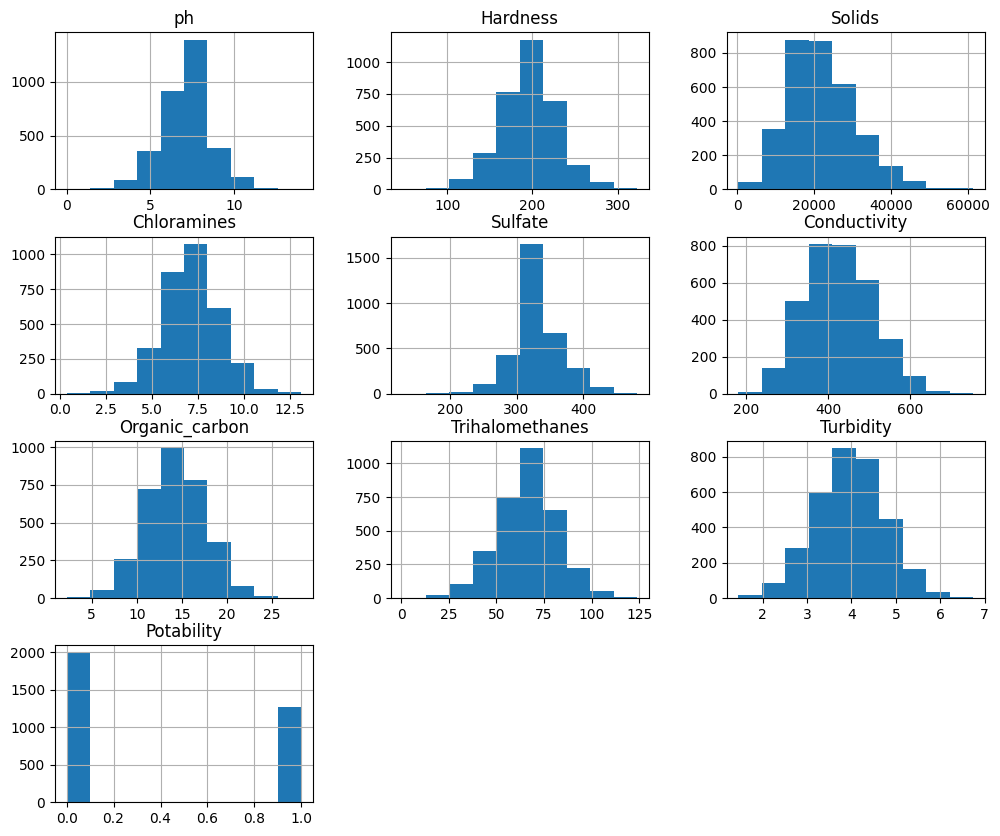

In [10]:
#4. Data Visualization (EDA)
#4.1 Distribution Plots
df.hist(figsize=(12,10))
plt.show()

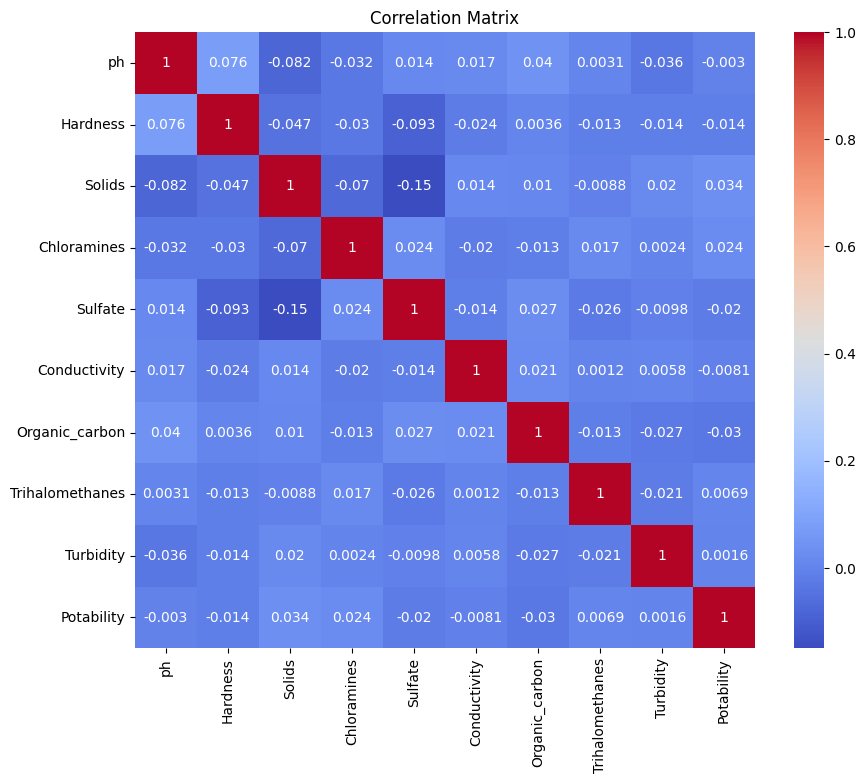

In [11]:
#4.2 Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

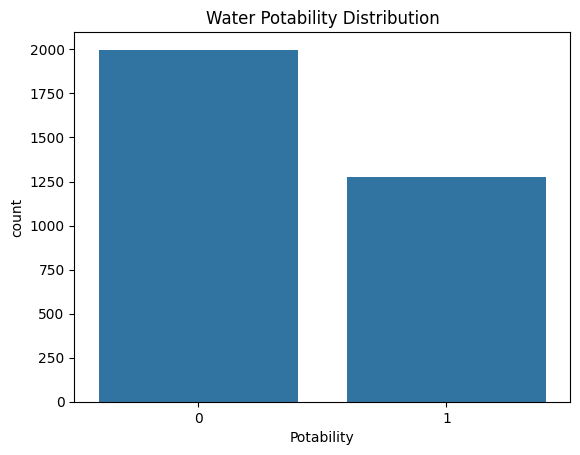

In [12]:
#4.3 Target Variable Distribution
sns.countplot(x='Potability', data=df)
plt.title("Water Potability Distribution")
plt.show()

In [13]:
#5. Feature Engineering
# Example feature
df['Hardness_pH_ratio'] = df['Hardness'] / df['ph']

In [14]:
#6. Split Features & Target
X = df.drop('Potability', axis=1)
y = df['Potability']

In [23]:
#7. Handle Class Imbalance (SMOTE)
#i have extremely large numbers that the SMOTE algorithm cannot process.
#divided by zero or a very small number, which likely occurred when the Hardness_pH_ratio feature was created.
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(y.value_counts())
print(y_res.value_counts())

Potability
0    1998
1    1278
Name: count, dtype: int64
Potability
0    1998
1    1998
Name: count, dtype: int64


In [24]:
#8. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42)

In [27]:
#9. Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
#10. Model Training
#10.1 SVM
svm = SVC(probability=True)
svm.fit(X_train, y_train)

SVC(probability=True)

In [29]:
#10.2 Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [30]:
#10.3 KNN
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [31]:
#10.4 Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [32]:
#11. Model Evaluation Function
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Classification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.show()

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
    plt.plot([0,1],[0,1],'--')
    plt.legend()
    plt.title("ROC Curve")
    plt.show()

SVM Results
Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.66      0.67       394
           1       0.68      0.69      0.69       406

    accuracy                           0.68       800
   macro avg       0.68      0.68      0.68       800
weighted avg       0.68      0.68      0.68       800



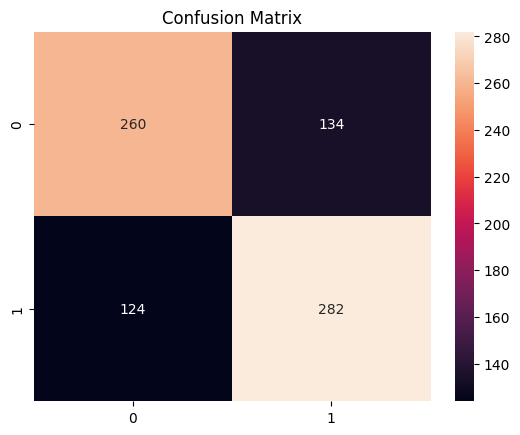

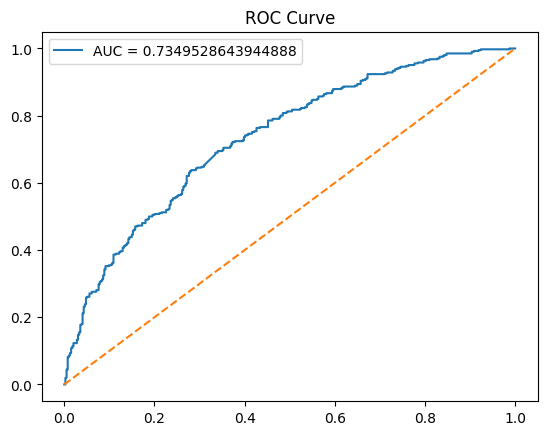

Random Forest Results
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.72      0.71       394
           1       0.72      0.72      0.72       406

    accuracy                           0.72       800
   macro avg       0.72      0.72      0.72       800
weighted avg       0.72      0.72      0.72       800



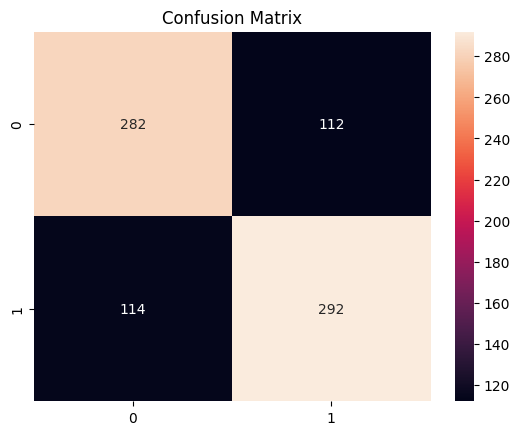

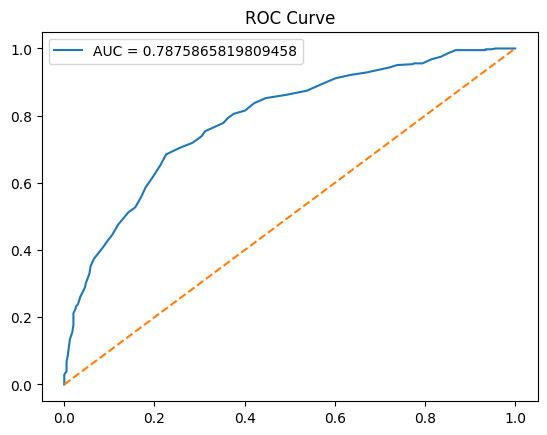

KNN Results
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.62      0.63       394
           1       0.65      0.67      0.66       406

    accuracy                           0.65       800
   macro avg       0.65      0.65      0.65       800
weighted avg       0.65      0.65      0.65       800



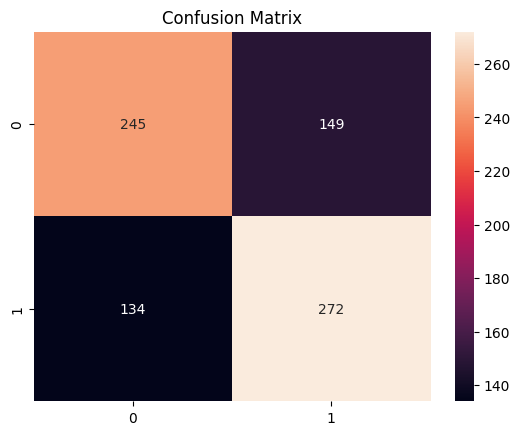

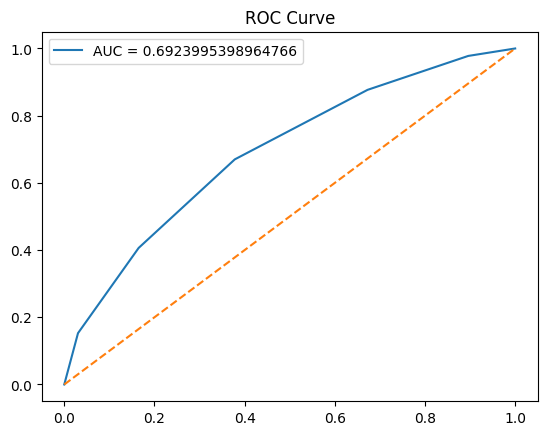

Decision Tree Results
Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.63      0.61       394
           1       0.62      0.60      0.61       406

    accuracy                           0.61       800
   macro avg       0.61      0.61      0.61       800
weighted avg       0.61      0.61      0.61       800



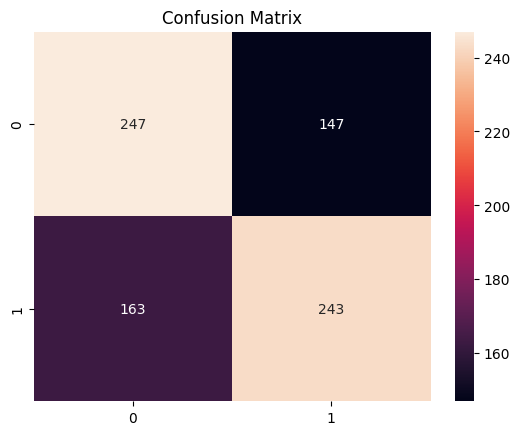

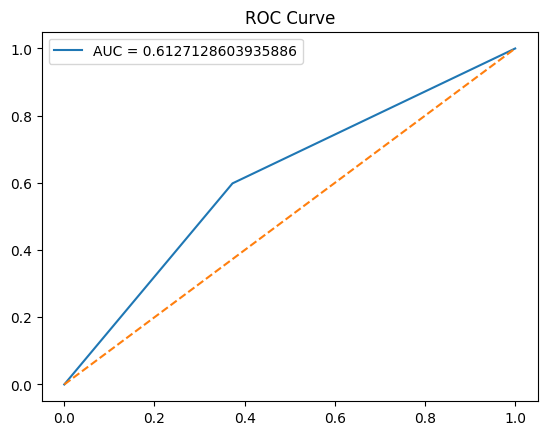

In [33]:
#12. Evaluate All Models
print("SVM Results")
evaluate_model(svm, X_test, y_test)

print("Random Forest Results")
evaluate_model(rf, X_test, y_test)

print("KNN Results")
evaluate_model(knn, X_test, y_test)

print("Decision Tree Results")
evaluate_model(dt, X_test, y_test)

In [34]:
#13. Hyperparameter Tuning (Random Forest Example)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
best_model = grid.best_estimator_

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


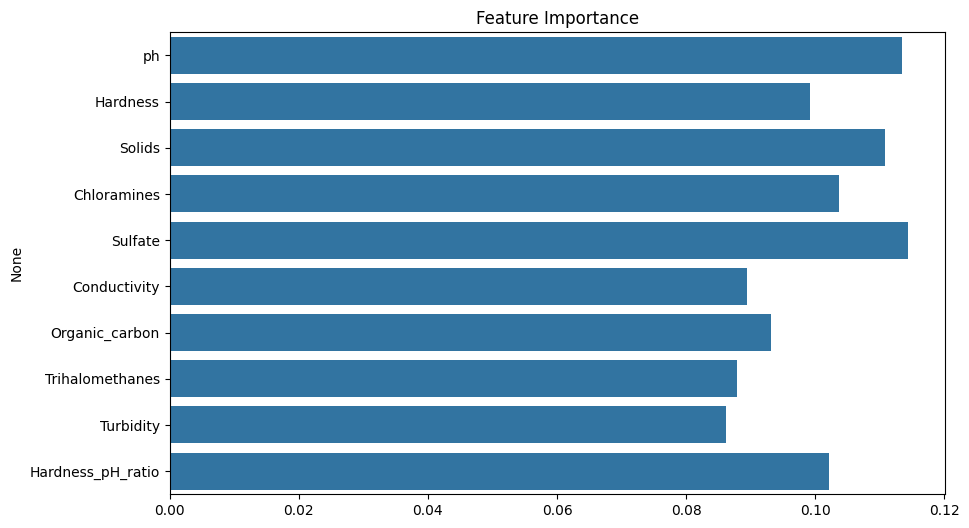

In [35]:
#14. Feature Importance
importances = best_model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance")
plt.show()

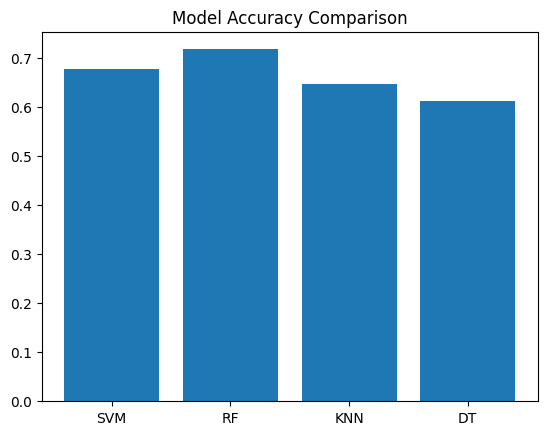

In [36]:
#15. Model Comparison Chart
models = ['SVM', 'RF', 'KNN', 'DT']
scores = [
    svm.score(X_test, y_test),
    rf.score(X_test, y_test),
    knn.score(X_test, y_test),
    dt.score(X_test, y_test)
]

plt.bar(models, scores)
plt.title("Model Accuracy Comparison")
plt.show()

In [39]:
#17. Deliverables Structure
Water_Potability_Project/
│
├── notebook.ipynb
├── report.pdf
├── dataset.csv
└── dashboard(optional)

SyntaxError: invalid character '│' (U+2502) (3446899000.py, line 3)